# CAM-Guided Attention Supervision dengan Prior Hematoxylin
### Hinge Containment Loss untuk Klasifikasi Histopatologi

Notebook ini mengimplementasikan **Opsi B**: CAM disupervisi oleh prior eksternal yang murah
(kanal Hematoxylin hasil dekonvolusi warna), dengan **hinge containment loss** sebagai
kontribusi metodologis.

---

## Cara pakai

1. **Runtime > Change runtime type > GPU** (T4 sudah cukup).
2. Jalankan sel dari atas ke bawah.
3. Kalau koneksi putus / kena limit Colab: **cukup jalankan ulang semua sel dari atas**.
   Notebook akan otomatis melanjutkan dari checkpoint terakhir, bukan mulai dari nol.

## Yang di-checkpoint

| Level | Mekanisme |
|---|---|
| Prior Hematoxylin | Cache `.npy` di Drive, patch yang sudah dihitung dilewati |
| Dalam satu epoch | Simpan tiap `save_every_n_steps`, resume ke batch yang tepat |
| Antar epoch | `ckpt_last.pt` + `ckpt_best.pt` (atomic write) |
| Antar run eksperimen | File penanda `DONE`, run yang selesai dilewati |
| RNG | State torch / cuda / numpy / random ikut disimpan |

## Eksperimen yang dijalankan

- **E0** Baseline vs Proposed vs baseline loss lain (Dice, L2, KL)
- **E1** Degradasi prior (dilate / erode / dropout / shift) &rarr; grafik ketahanan
- **E2** Injeksi shortcut sintetis
- **E3** Kurva low-data (5% / 10% / 25% / 50% / 100%)
- **E4** Kontrol prior acak

---
## 1. Mount Google Drive & struktur folder

In [1]:
import os, sys, json, time, shutil, random, math, re, glob, hashlib, traceback
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")

if IN_COLAB:
    from google.colab import drive
    if not os.path.ismount("/content/drive"):
        drive.mount("/content/drive", force_remount=False)
    DRIVE_ROOT = "/content/drive/MyDrive"
else:
    DRIVE_ROOT = os.path.expanduser("~")

# Semua artefak penelitian disimpan di sini. Ganti kalau mau folder lain.
PROJECT = os.path.join(DRIVE_ROOT, "cam_guided_histo")

DIRS = {
    "project": PROJECT,
    "data":    os.path.join(PROJECT, "data"),
    "priors":  os.path.join(PROJECT, "priors"),
    "runs":    os.path.join(PROJECT, "runs"),
    "results": os.path.join(PROJECT, "results"),
    "figs":    os.path.join(PROJECT, "figures"),
    "cache":   "/content/_cache" if IN_COLAB else "/tmp/_cache",
}
for p in DIRS.values():
    os.makedirs(p, exist_ok=True)

print("Project dir :", PROJECT)
for k, v in DIRS.items():
    print(f"  {k:8s} -> {v}")

Mounted at /content/drive
Project dir : /content/drive/MyDrive/cam_guided_histo
  project  -> /content/drive/MyDrive/cam_guided_histo
  data     -> /content/drive/MyDrive/cam_guided_histo/data
  priors   -> /content/drive/MyDrive/cam_guided_histo/priors
  runs     -> /content/drive/MyDrive/cam_guided_histo/runs
  results  -> /content/drive/MyDrive/cam_guided_histo/results
  figs     -> /content/drive/MyDrive/cam_guided_histo/figures
  cache    -> /content/_cache


---
## 2. Dependencies

In [2]:
import subprocess

def pip_install(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

need = []
for mod, pkg in [("skimage", "scikit-image"), ("cv2", "opencv-python-headless"),
                 ("sklearn", "scikit-learn"), ("tqdm", "tqdm"), ("gdown", "gdown")]:
    try:
        __import__(mod)
    except ImportError:
        need.append(pkg)
if need:
    print("Installing:", need)
    pip_install(need)

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import matplotlib.pyplot as plt
from skimage.color import rgb2hed, hed2rgb
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU  :", torch.cuda.get_device_name(0))

torch 2.11.0+cpu | device: cpu


---
## 3. Konfigurasi

Semua hyperparameter ada di satu tempat. `CFG` disimpan ke Drive bersama tiap run
supaya hasilnya reproducible.

In [3]:
from dataclasses import dataclass, asdict, field, replace

@dataclass
class Config:
    # --- data ---
    dataset:        str  = "LUAD-HistoSeg"   # nama folder di DIRS["data"]
    class_names:    tuple = ("TE", "NEC", "LYM", "TAS")
    img_size:       int  = 224
    ignore_index:   int  = 4                 # nilai piksel 'background/exclude' pada mask GT
    train_fraction: float = 1.0              # untuk E3 low-data

    # --- prior ---
    prior_kind:     str  = "hema"            # hema | tissue | none
    prior_cache_hw: int  = 56                # resolusi cache prior (di-resize ke grid CAM saat load)
    prior_sigma:    float = 3.0              # blur pada kanal H (densitas inti, bukan inti individual)
    prior_pct:      float = 60.0             # persentil threshold
    prior_degrade:  str  = "none"            # none|dilate2|dilate3|erode2|erode3|drop20|drop40|drop60|shift3
    prior_random:   bool = False             # E4: acak prior antar sampel

    # --- model ---
    backbone:       str  = "resnet18"
    dilate_last:    bool = True              # layer4 stride->dilation, CAM 14x14 bukan 7x7
    freeze_stem:    bool = True

    # --- loss ---
    align_type:     str  = "hinge"           # none | hinge | dice | l2 | kl
    rho:            float = 0.75             # target containment (dipakai align_type='hinge')
    rho_per_class:  tuple = ()               # kosong = pakai rho tunggal untuk semua kelas
    lambda_align:   float = 1.0
    gamma_neg:      float = 0.1              # supresi CAM kelas absen
    warmup_epochs:  int  = 5

    # --- shortcut (E2) ---
    shortcut:       bool = False
    shortcut_p:     float = 0.9
    shortcut_size:  int  = 24

    # --- training ---
    epochs:         int  = 30
    batch_size:     int  = 64
    lr:             float = 3e-4
    weight_decay:   float = 1e-4
    optimizer:      str  = "adamw"
    num_workers:    int  = 2
    amp:            bool = True
    hed_jitter_p:   float = 0.5
    hed_jitter_s:   float = 0.05
    seed:           int  = 2024
    save_every_n_steps: int = 100            # checkpoint tengah-epoch
    select_metric:  str  = "macro_f1"
    keep_best_weights: bool = True           # setelah DONE, simpan bobot ramping saja (hemat Drive)

    # --- evaluasi ---
    eval_faithfulness: bool = True
    faith_n_samples:   int  = 200
    faith_steps:       int  = 20

    @property
    def n_classes(self):
        return len(self.class_names)

CFG = Config()
print(json.dumps(asdict(CFG), indent=2, default=str))

{
  "dataset": "LUAD-HistoSeg",
  "class_names": [
    "TE",
    "NEC",
    "LYM",
    "TAS"
  ],
  "img_size": 224,
  "ignore_index": 4,
  "train_fraction": 1.0,
  "prior_kind": "hema",
  "prior_cache_hw": 56,
  "prior_sigma": 3.0,
  "prior_pct": 60.0,
  "prior_degrade": "none",
  "prior_random": false,
  "backbone": "resnet18",
  "dilate_last": true,
  "freeze_stem": true,
  "align_type": "hinge",
  "rho": 0.75,
  "rho_per_class": [],
  "lambda_align": 1.0,
  "gamma_neg": 0.1,
  "warmup_epochs": 5,
  "shortcut": false,
  "shortcut_p": 0.9,
  "shortcut_size": 24,
  "epochs": 30,
  "batch_size": 64,
  "lr": 0.0003,
  "weight_decay": 0.0001,
  "optimizer": "adamw",
  "num_workers": 2,
  "amp": true,
  "hed_jitter_p": 0.5,
  "hed_jitter_s": 0.05,
  "seed": 2024,
  "save_every_n_steps": 100,
  "select_metric": "macro_f1",
  "keep_best_weights": true,
  "eval_faithfulness": true,
  "faith_n_samples": 200,
  "faith_steps": 20
}


---
## 4. Menyiapkan dataset

Tiga jalur, dicek berurutan:

1. Dataset sudah ada di `Drive/cam_guided_histo/data/<nama>` &rarr; langsung dipakai.
2. Ada file zip di Drive &rarr; diekstrak.
3. `USE_SYNTHETIC = True` &rarr; dibuat dataset tiruan supaya notebook bisa diuji
   ujung-ke-ujung sebelum dataset asli tersedia.

**Untuk LUAD-HistoSeg asli:** unduh dari repo `github.com/ChuHan89/WSSS-Tissue`
(link Google Drive ada di README-nya), lalu taruh zip-nya di Drive dan isi `ZIP_PATH`
atau `GDOWN_ID` di bawah.

Struktur yang dikenali otomatis:
```
<dataset>/train/*.png                  # nama file mengandung label multi-hot, mis. ...-[1 0 0 0].png
<dataset>/val/img/*.png  + val/mask/*.png
<dataset>/test/img/*.png + test/mask/*.png
```
Struktur folder-per-kelas (mis. NCT-CRC-HE-100K) juga didukung otomatis.

In [4]:
USE_SYNTHETIC = True     # << set False kalau dataset asli sudah tersedia
ZIP_PATH      = ""       # mis. "/content/drive/MyDrive/LUAD-HistoSeg.zip"
GDOWN_ID      = ""       # atau isi file-id Google Drive

DATA_DIR = os.path.join(DIRS["data"], CFG.dataset)


def _make_synth_patch(rng, cls, size=224):
    # latar merah muda ala eosin
    img = np.zeros((size, size, 3), np.float32)
    img[..., 0] = 232 + rng.normal(0, 4, (size, size))
    img[..., 1] = 190 + rng.normal(0, 5, (size, size))
    img[..., 2] = 212 + rng.normal(0, 4, (size, size))
    mask = np.full((size, size), 255, np.uint8)
    # tiap kelas = densitas & ukuran 'inti' berbeda
    spec = {0: (140, 7), 1: (25, 14), 2: (260, 4), 3: (60, 9)}
    n, r = spec[cls]
    cx0, cy0 = rng.integers(20, size - 20), rng.integers(20, size - 20)
    for _ in range(n):
        cx = int(np.clip(rng.normal(cx0, size / 4), 0, size - 1))
        cy = int(np.clip(rng.normal(cy0, size / 4), 0, size - 1))
        rr = max(2, int(rng.normal(r, 1.5)))
        cv2.circle(img, (cx, cy), rr, (90, 60, 150), -1)   # ungu ala hematoxylin
        cv2.circle(mask, (cx, cy), rr + 6, int(cls), -1)
    img = np.clip(img + rng.normal(0, 3, img.shape), 0, 255).astype(np.uint8)
    return img, mask


def build_synthetic(root, n_train=1200, n_val=150, n_test=150, size=224, n_cls=4, seed=0):
    rng = np.random.default_rng(seed)
    os.makedirs(os.path.join(root, "train"), exist_ok=True)
    for sp in ("val", "test"):
        os.makedirs(os.path.join(root, sp, "img"), exist_ok=True)
        os.makedirs(os.path.join(root, sp, "mask"), exist_ok=True)
    for i in range(n_train):
        c = int(rng.integers(0, n_cls))
        img, _ = _make_synth_patch(rng, c, size)
        lab = np.zeros(n_cls, int); lab[c] = 1
        if rng.random() < 0.25:                      # sebagian multi-label
            lab[int(rng.integers(0, n_cls))] = 1
        tag = "[" + " ".join(map(str, lab)) + "]"
        cv2.imwrite(os.path.join(root, "train", f"s{i:06d}-{tag}.png"), img[:, :, ::-1])
    for sp, n in (("val", n_val), ("test", n_test)):
        for i in range(n):
            c = int(rng.integers(0, n_cls))
            img, m = _make_synth_patch(rng, c, size)
            lab = np.zeros(n_cls, int); lab[c] = 1
            tag = "[" + " ".join(map(str, lab)) + "]"
            cv2.imwrite(os.path.join(root, sp, "img", f"s{i:06d}-{tag}.png"), img[:, :, ::-1])
            cv2.imwrite(os.path.join(root, sp, "mask", f"s{i:06d}-{tag}.png"), m)
    print(f"Synthetic dataset dibuat di {root}")


def ensure_dataset():
    if os.path.isdir(DATA_DIR) and len(glob.glob(os.path.join(DATA_DIR, "**", "*.png"), recursive=True)) > 50:
        print("Dataset sudah ada:", DATA_DIR); return
    if ZIP_PATH and os.path.exists(ZIP_PATH):
        print("Mengekstrak", ZIP_PATH)
        shutil.unpack_archive(ZIP_PATH, DIRS["data"]); print("Selesai."); return
    if GDOWN_ID:
        import gdown
        z = os.path.join(DIRS["cache"], "dataset.zip")
        gdown.download(id=GDOWN_ID, output=z, quiet=False)
        shutil.unpack_archive(z, DIRS["data"]); print("Selesai."); return
    if USE_SYNTHETIC:
        build_synthetic(DATA_DIR, n_cls=CFG.n_classes, size=CFG.img_size); return
    raise FileNotFoundError("Dataset tidak ditemukan. Isi ZIP_PATH / GDOWN_ID, atau set USE_SYNTHETIC=True.")

ensure_dataset()
print(sorted(os.listdir(DATA_DIR)))

Dataset sudah ada: /content/drive/MyDrive/cam_guided_histo/data/LUAD-HistoSeg
['test', 'train', 'val']


---
## 5. Index dataset

Membaca daftar file sekali, lalu menyimpan index JSON supaya scan folder Drive
yang lambat tidak diulang tiap kali notebook direstart.

In [5]:
LABEL_RE = re.compile(r"\[([01](?:[\s,]+[01])*)\]")
IMG_EXT = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")


def parse_label_from_name(name, n_cls):
    m = LABEL_RE.search(name)
    if m:
        v = [int(x) for x in re.split(r"[\s,]+", m.group(1).strip()) if x != ""]
        if len(v) == n_cls:
            return v
    return None


def scan_split(root, split, class_names):
    n_cls = len(class_names)
    d = os.path.join(root, split)
    if not os.path.isdir(d):
        for alt in (split.replace("val", "valid"), split.replace("test", "testing")):
            if os.path.isdir(os.path.join(root, alt)):
                d = os.path.join(root, alt); break
    if not os.path.isdir(d):
        return []

    img_dir = os.path.join(d, "img") if os.path.isdir(os.path.join(d, "img")) else d
    mask_dir = None
    for cand in ("mask", "masks", "label"):
        if os.path.isdir(os.path.join(d, cand)):
            mask_dir = os.path.join(d, cand); break

    items, files = [], []
    for f in sorted(os.listdir(img_dir)):
        if f.lower().endswith(IMG_EXT):
            files.append((os.path.join(img_dir, f), f))

    if files:                                        # file datar
        for path, f in files:
            lab = parse_label_from_name(f, n_cls)
            if lab is None:
                continue
            mp = None
            if mask_dir:
                cand = os.path.join(mask_dir, f)
                if os.path.exists(cand):
                    mp = cand
                else:
                    stem = os.path.splitext(f)[0]
                    g = glob.glob(os.path.join(mask_dir, stem + ".*"))
                    mp = g[0] if g else None
            items.append({"img": path, "mask": mp, "label": lab})
    else:                                            # folder-per-kelas
        name2idx = {c.lower(): i for i, c in enumerate(class_names)}
        for sub in sorted(os.listdir(img_dir)):
            sd = os.path.join(img_dir, sub)
            if not os.path.isdir(sd):
                continue
            ci = name2idx.get(sub.lower())
            if ci is None:
                continue
            for f in sorted(os.listdir(sd)):
                if f.lower().endswith(IMG_EXT):
                    lab = [0] * n_cls; lab[ci] = 1
                    items.append({"img": os.path.join(sd, f), "mask": None, "label": lab})
    return items


def build_index(force=False):
    idx_path = os.path.join(DIRS["data"], f"index_{CFG.dataset}.json")
    if os.path.exists(idx_path) and not force:
        with open(idx_path) as f:
            return json.load(f)
    index = {sp: scan_split(DATA_DIR, sp, CFG.class_names) for sp in ("train", "val", "test")}
    if not index["val"] and index["test"]:
        n = max(1, len(index["test"]) // 2)
        index["val"], index["test"] = index["test"][:n], index["test"][n:]
    with open(idx_path, "w") as f:
        json.dump(index, f)
    return index

INDEX = build_index(force=False)
for sp in ("train", "val", "test"):
    n = len(INDEX[sp]); nm = sum(1 for it in INDEX[sp] if it["mask"])
    print(f"{sp:5s}: {n:6d} patch | {nm:6d} punya mask GT")

Y = np.array([it["label"] for it in INDEX["train"]]) if INDEX["train"] else np.zeros((0, CFG.n_classes))
if len(Y):
    print("\nDistribusi kelas (train):")
    for i, c in enumerate(CFG.class_names):
        print(f"  {c:5s}: {int(Y[:, i].sum()):6d}  ({Y[:, i].mean() * 100:5.1f}%)")

train:   1200 patch |      0 punya mask GT
val  :    150 patch |    150 punya mask GT
test :    150 patch |    150 punya mask GT

Distribusi kelas (train):
  TE   :    371  ( 30.9%)
  NEC  :    353  ( 29.4%)
  LYM  :    333  ( 27.8%)
  TAS  :    354  ( 29.5%)


---
## 6. Precompute prior Hematoxylin (bisa dilanjut)

Prior dihitung **sekali, offline**, lalu disimpan sebagai array `uint8` berukuran
`56x56` per patch. Ini yang membuat biaya prior saat training menjadi nol.

Kalau proses terputus, jalankan ulang sel ini: patch yang sudah selesai dilewati.

Biaya penyimpanan: 56x56 = 3.1 KB per patch. Untuk 17.000 patch sekitar 53 MB.

[train] prior sudah lengkap (1200)
[val] prior sudah lengkap (150)
[test] prior sudah lengkap (150)

Total waktu prior: 0.5 s


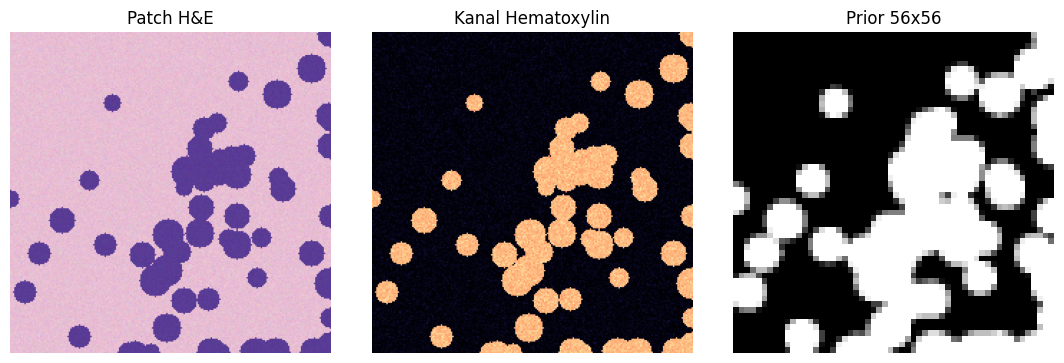

In [6]:
from concurrent.futures import ProcessPoolExecutor

def hema_prior_from_rgb(rgb, out_hw=56, sigma=3.0, pct=60.0):
    # Kanal Hematoxylin = peta densitas kromatin inti sel. Tanpa model deep learning.
    hed = rgb2hed(rgb.astype(np.float32) / 255.0)
    H = hed[..., 0]
    rng_ = H.max() - H.min()
    H = (H - H.min()) / (rng_ + 1e-8)
    if sigma > 0:
        H = cv2.GaussianBlur(H, (0, 0), sigma)
    thr = np.percentile(H, pct)
    P = (H > thr).astype(np.float32)
    return (cv2.resize(P, (out_hw, out_hw), interpolation=cv2.INTER_AREA) * 255).astype(np.uint8)


def tissue_prior_from_rgb(rgb, out_hw=56):
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    s = hsv[..., 1]
    _, th = cv2.threshold(s, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))
    return cv2.resize(th, (out_hw, out_hw), interpolation=cv2.INTER_AREA)


def _worker(args):
    path, kind, hw, sigma, pct = args
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        return None
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    if kind == "hema":
        return hema_prior_from_rgb(rgb, hw, sigma, pct)
    if kind == "tissue":
        return tissue_prior_from_rgb(rgb, hw)
    return np.full((hw, hw), 255, np.uint8)


def prior_store_paths(split):
    tag = f"{CFG.dataset}_{split}_{CFG.prior_kind}_{CFG.prior_cache_hw}"
    return (os.path.join(DIRS["priors"], tag + ".npy"),
            os.path.join(DIRS["priors"], tag + "_state.json"))


def precompute_priors(split, chunk=512):
    items = INDEX[split]
    if not items:
        return None
    arr_p, st_p = prior_store_paths(split)
    n, hw = len(items), CFG.prior_cache_hw

    if os.path.exists(arr_p) and os.path.exists(st_p):
        with open(st_p) as f:
            st = json.load(f)
        if st.get("n") != n:
            st = {"n": n, "done": 0}
            np.lib.format.open_memmap(arr_p, mode="w+", dtype=np.uint8, shape=(n, hw, hw))
    else:
        st = {"n": n, "done": 0}
        np.lib.format.open_memmap(arr_p, mode="w+", dtype=np.uint8, shape=(n, hw, hw))

    if st["done"] >= n:
        print(f"[{split}] prior sudah lengkap ({n})"); return arr_p

    mm = np.lib.format.open_memmap(arr_p, mode="r+")
    start = st["done"]
    print(f"[{split}] menghitung prior {start} -> {n}")
    pbar = tqdm(total=n - start, desc=f"prior:{split}")
    workers = max(1, (os.cpu_count() or 2))
    with ProcessPoolExecutor(max_workers=workers) as ex:
        for s in range(start, n, chunk):
            e = min(s + chunk, n)
            args = [(items[i]["img"], CFG.prior_kind, hw, CFG.prior_sigma, CFG.prior_pct)
                    for i in range(s, e)]
            for j, out in enumerate(ex.map(_worker, args, chunksize=16)):
                mm[s + j] = out if out is not None else 0
            mm.flush()
            st["done"] = e
            with open(st_p, "w") as f:
                json.dump(st, f)
            pbar.update(e - s)
    pbar.close()
    del mm
    print(f"[{split}] selesai -> {arr_p}")
    return arr_p


t0 = time.time()
PRIOR_PATHS = {sp: precompute_priors(sp) for sp in ("train", "val", "test")}
print(f"\nTotal waktu prior: {time.time() - t0:.1f} s")

# pratinjau
it = INDEX["train"][0]
rgb0 = cv2.cvtColor(cv2.imread(it["img"]), cv2.COLOR_BGR2RGB)
p0 = np.load(PRIOR_PATHS["train"], mmap_mode="r")[0]
fig, ax = plt.subplots(1, 3, figsize=(11, 3.6))
ax[0].imshow(rgb0); ax[0].set_title("Patch H&E")
ax[1].imshow(rgb2hed(rgb0 / 255.0)[..., 0], cmap="magma"); ax[1].set_title("Kanal Hematoxylin")
ax[2].imshow(p0, cmap="gray"); ax[2].set_title(f"Prior {CFG.prior_cache_hw}x{CFG.prior_cache_hw}")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

---
## 7. Degradasi prior (E1) & injeksi shortcut (E2)

**E1** merusak prior secara terkendali. Inilah eksperimen inti yang membedakan
hinge containment dari Dice/L2: prediksinya, Dice/L2 runtuh cepat sementara hinge
menurun landai.

**E2** menempelkan blok warna non-H&E di sudut patch yang berkorelasi 90% dengan label
pada training set dan dihapus pada test set. Prior di area blok di-nol-kan, karena
generator prior yang dijalankan pada citra terkorupsi memang akan melihat blok itu
sebagai bukan-inti-sel.

In [7]:
def degrade_prior(P, mode, rng):
    # P: float32 [0,1], shape (hw,hw). Satuan kernel = grid prior, bukan piksel citra.
    if mode == "none" or not mode:
        return P
    if mode.startswith("dilate"):
        k = int(mode[6:]) * 2 + 1
        return cv2.dilate(P, np.ones((k, k), np.uint8))
    if mode.startswith("erode"):
        k = int(mode[5:]) * 2 + 1
        return cv2.erode(P, np.ones((k, k), np.uint8))
    if mode.startswith("drop"):
        p = int(mode[4:]) / 100.0
        keep = (rng.random(P.shape) > p).astype(np.float32)
        return P * keep
    if mode.startswith("shift"):
        s = int(mode[5:])
        dx, dy = rng.integers(-s, s + 1), rng.integers(-s, s + 1)
        return np.roll(np.roll(P, dy, axis=0), dx, axis=1)
    if mode == "invert":
        return 1.0 - P
    raise ValueError(f"mode degradasi tidak dikenal: {mode}")


SHORTCUT_COLORS = [(0, 255, 0), (255, 255, 0), (0, 255, 255), (255, 128, 0),
                   (128, 255, 128), (255, 200, 0), (0, 200, 255), (255, 160, 60)]


def inject_shortcut(img, prior, cls, size, rng):
    # img: uint8 HxWx3 ; prior: float32 hw x hw
    H, W = img.shape[:2]
    hw = prior.shape[0]
    corner = int(rng.integers(0, 4))
    y0 = 0 if corner in (0, 1) else H - size
    x0 = 0 if corner in (0, 2) else W - size
    img = img.copy()
    img[y0:y0 + size, x0:x0 + size] = SHORTCUT_COLORS[cls % len(SHORTCUT_COLORS)]
    sy0, sx0 = int(y0 / H * hw), int(x0 / W * hw)
    sy1, sx1 = int(math.ceil((y0 + size) / H * hw)), int(math.ceil((x0 + size) / W * hw))
    prior = prior.copy()
    prior[sy0:sy1, sx0:sx1] = 0.0
    return img, prior

---
## 8. Dataset & augmentasi

Yang kritis: transformasi geometris harus diterapkan **identik** pada citra dan prior.
Hanya flip dan rotasi kelipatan 90 derajat yang dipakai, karena keduanya punya invers
eksak dan tidak memperkenalkan artefak interpolasi yang mengotori sinyal alignment.

In [8]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], np.float32)


def hed_jitter(img_u8, sigma):
    hed = rgb2hed(img_u8.astype(np.float32) / 255.0)
    a = 1.0 + np.random.uniform(-sigma, sigma, 3).astype(np.float32)
    b = np.random.uniform(-sigma, sigma, 3).astype(np.float32)
    out = hed2rgb(hed * a + b)
    return (np.clip(out, 0, 1) * 255).astype(np.uint8)


class PatchDataset(Dataset):
    def __init__(self, split, cfg, train=False, indices=None):
        self.cfg, self.split, self.train = cfg, split, train
        self.items = INDEX[split]
        self.indices = list(range(len(self.items))) if indices is None else list(indices)
        self.prior_path = PRIOR_PATHS.get(split)
        self.prior_mm = None
        self.cam_hw = cfg.img_size // (16 if cfg.dilate_last else 32)

    def __len__(self):
        return len(self.indices)

    def _priors(self):
        if self.prior_mm is None and self.prior_path:
            self.prior_mm = np.load(self.prior_path, mmap_mode="r")
        return self.prior_mm

    def __getitem__(self, i):
        cfg = self.cfg
        gi = self.indices[i]
        it = self.items[gi]
        rng = np.random.default_rng(abs(hash((cfg.seed, self.split, gi, int(time.time() * 1e6) % 100000))) % (2**32))

        bgr = cv2.imread(it["img"], cv2.IMREAD_COLOR)
        img = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        if img.shape[0] != cfg.img_size or img.shape[1] != cfg.img_size:
            img = cv2.resize(img, (cfg.img_size, cfg.img_size), interpolation=cv2.INTER_AREA)

        y = np.array(it["label"], np.float32)

        pm = self._priors()
        if pm is not None and cfg.prior_kind != "none":
            P = pm[gi].astype(np.float32) / 255.0
        else:
            P = np.ones((cfg.prior_cache_hw, cfg.prior_cache_hw), np.float32)

        # mask GT (hanya val/test) untuk metrik lokalisasi
        if it["mask"]:
            m = cv2.imread(it["mask"], cv2.IMREAD_GRAYSCALE)
            if m.shape[0] != cfg.img_size:
                m = cv2.resize(m, (cfg.img_size, cfg.img_size), interpolation=cv2.INTER_NEAREST)
        else:
            m = np.full((cfg.img_size, cfg.img_size), 255, np.uint8)

        if self.train:
            P = degrade_prior(P, cfg.prior_degrade, rng)
            if cfg.shortcut and rng.random() < cfg.shortcut_p:
                cls = int(np.argmax(y))
                img, P = inject_shortcut(img, P, cls, cfg.shortcut_size, rng)
            if rng.random() < 0.5:
                img, P, m = img[:, ::-1], P[:, ::-1], m[:, ::-1]
            if rng.random() < 0.5:
                img, P, m = img[::-1], P[::-1], m[::-1]
            k = int(rng.integers(0, 4))
            if k:
                img, P, m = np.rot90(img, k), np.rot90(P, k), np.rot90(m, k)
            img, P, m = np.ascontiguousarray(img), np.ascontiguousarray(P), np.ascontiguousarray(m)
            if cfg.hed_jitter_p > 0 and rng.random() < cfg.hed_jitter_p:
                img = hed_jitter(img, cfg.hed_jitter_s)

        P = cv2.resize(P, (self.cam_hw, self.cam_hw), interpolation=cv2.INTER_AREA)
        P = (P > 0.5).astype(np.float32)

        x = img.astype(np.float32) / 255.0
        x = (x - IMAGENET_MEAN) / IMAGENET_STD
        x = torch.from_numpy(x.transpose(2, 0, 1).copy())

        return {"x": x,
                "y": torch.from_numpy(y),
                "prior": torch.from_numpy(P.copy()).unsqueeze(0),
                "mask": torch.from_numpy(m.astype(np.int64).copy()),
                "idx": gi}


def make_loaders(cfg, epoch_seed=0):
    n_tr = len(INDEX["train"])
    if cfg.train_fraction < 1.0:
        r = np.random.default_rng(cfg.seed)
        keep = r.permutation(n_tr)[:max(1, int(n_tr * cfg.train_fraction))]
    else:
        keep = None

    tr = PatchDataset("train", cfg, train=True, indices=keep)
    va = PatchDataset("val", cfg, train=False)
    te = PatchDataset("test", cfg, train=False)

    g = torch.Generator(); g.manual_seed(cfg.seed * 1000 + epoch_seed)
    ltr = DataLoader(tr, batch_size=cfg.batch_size, shuffle=True, generator=g,
                     num_workers=cfg.num_workers, pin_memory=True, drop_last=True,
                     persistent_workers=cfg.num_workers > 0)
    lva = DataLoader(va, batch_size=cfg.batch_size * 2, shuffle=False,
                     num_workers=cfg.num_workers, pin_memory=True)
    lte = DataLoader(te, batch_size=cfg.batch_size * 2, shuffle=False,
                     num_workers=cfg.num_workers, pin_memory=True)
    return ltr, lva, lte


_ltr, _lva, _lte = make_loaders(CFG)
_b = next(iter(_ltr))
print({k: tuple(v.shape) for k, v in _b.items() if torch.is_tensor(v)})
print("Grid CAM:", _ltr.dataset.cam_hw, "x", _ltr.dataset.cam_hw)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'x': (64, 3, 224, 224), 'y': (64, 4), 'prior': (64, 1, 14, 14), 'mask': (64, 224, 224), 'idx': (64,)}
Grid CAM: 14 x 14


---
## 9. Model

**Aturan hemat komputasi yang paling penting:** pakai CAM vanilla (GAP + FC),
bukan Grad-CAM. Pada arsitektur ini `logit_c = mean(CAM_c)`, sehingga CAM adalah
kuantitas antara yang sudah ada di graf komputasi. Biayanya satu konvolusi 1x1.

Grad-CAM di dalam loss memerlukan `create_graph=True` (gradien orde dua), yang membuat
training 2&ndash;3 kali lebih lambat dan jauh lebih boros memori.

In [9]:
import torchvision

def make_dilated_(layer, dilation=2):
    # torchvision menolak replace_stride_with_dilation pada BasicBlock (resnet18/34),
    # jadi dilasi dipasang manual. Fungsi ini juga benar untuk Bottleneck (resnet50+).
    for m in layer.modules():
        if isinstance(m, nn.Conv2d):
            if m.stride == (2, 2):
                m.stride = (1, 1)
            if m.kernel_size == (3, 3):
                m.dilation = (dilation, dilation)
                m.padding = (dilation, dilation)
    return layer


class CAMNet(nn.Module):
    def __init__(self, n_classes, backbone="resnet18", dilate_last=True, freeze_stem=True):
        super().__init__()
        m = getattr(torchvision.models, backbone)(weights="IMAGENET1K_V1")
        if dilate_last:
            make_dilated_(m.layer4, dilation=2)   # CAM 14x14, bukan 7x7
        self.stem = nn.Sequential(m.conv1, m.bn1, m.relu, m.maxpool)
        self.layer1, self.layer2, self.layer3, self.layer4 = m.layer1, m.layer2, m.layer3, m.layer4
        feat_dim = m.fc.in_features
        # konv 1x1 lalu GAP == GAP lalu FC, tapi CAM-nya gratis
        self.classifier = nn.Conv2d(feat_dim, n_classes, 1, bias=False)
        nn.init.normal_(self.classifier.weight, std=0.01)
        if freeze_stem:
            for p in self.stem.parameters(): p.requires_grad = False
            for p in self.layer1.parameters(): p.requires_grad = False

    def forward(self, x):
        f = self.stem(x)
        f = self.layer1(f); f = self.layer2(f); f = self.layer3(f); f = self.layer4(f)
        cam = self.classifier(f)                 # B,C,h,w
        logits = cam.mean(dim=(2, 3))            # GAP -> logit, ekuivalen persis dengan CAM
        return logits, cam


def build_model(cfg):
    return CAMNet(cfg.n_classes, cfg.backbone, cfg.dilate_last, cfg.freeze_stem).to(DEVICE)


_m = build_model(CFG)
with torch.no_grad():
    lo, ca = _m(_b["x"][:2].to(DEVICE))
tot = sum(p.numel() for p in _m.parameters())
trn = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print("logits", tuple(lo.shape), "| cam", tuple(ca.shape))
print(f"params: {tot/1e6:.2f} M total, {trn/1e6:.2f} M trainable")
del _m

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 148MB/s] 


logits (2, 4) | cam (2, 4, 14, 14)
params: 11.18 M total, 11.02 M trainable


---
## 10. Loss

$$r_c = \frac{\sum \mathrm{ReLU}(A_c)\odot P}{\sum \mathrm{ReLU}(A_c)+\varepsilon}
\qquad
\mathcal{L}_{align}=\sum_{c:y_c=1}\mathrm{ReLU}(\rho_c - r_c)$$

Empat properti yang membuatnya bekerja:

1. **Satu sisi.** Tidak ada penalti karena gagal menutupi seluruh prior. Tidak semua
   inti sel diagnostik, tapi aktivasi di atas kaca kosong selalu salah.
2. **&rho; < 1.** Model boleh menyimpan sebagian atensi di luar prior, sehingga prior
   yang tidak sempurna tidak merusak pembelajaran.
3. **Gradien nol setelah puas.** Begitu r_c &ge; &rho;_c, term ini mati total.
4. **Scale-invariant.** Karena r_c adalah rasio, tidak perlu normalisasi min-max, yang
   selama ini jadi sumber gradien tidak stabil.

Baseline pembanding (Dice, L2, KL) diimplementasikan di sel yang sama untuk perbandingan
apple-to-apple.

In [10]:
EPS = 1e-6

def _norm_minmax(cam):
    B, C, h, w = cam.shape
    a = F.relu(cam).view(B, C, -1)
    mx = a.max(dim=2, keepdim=True)[0] + EPS
    return (a / mx).view(B, C, h, w)


def loss_hinge_containment(cam, prior, y, rho):
    a = F.relu(cam)
    num = (a * prior).sum(dim=(2, 3))
    den = a.sum(dim=(2, 3)) + EPS
    r = num / den                                   # B,C rasio massa atensi di dalam prior
    l = F.relu(rho.view(1, -1) - r) * y
    return l.sum() / (y.sum() + EPS), r.detach()


def loss_dice(cam, prior, y):
    a = _norm_minmax(cam)
    p = prior.expand_as(a)
    inter = (a * p).sum(dim=(2, 3))
    d = 1.0 - (2 * inter + 1.0) / (a.sum(dim=(2, 3)) + p.sum(dim=(2, 3)) + 1.0)
    return (d * y).sum() / (y.sum() + EPS)


def loss_l2(cam, prior, y):
    a = _norm_minmax(cam)
    e = ((a - prior.expand_as(a)) ** 2).mean(dim=(2, 3))
    return (e * y).sum() / (y.sum() + EPS)


def loss_kl(cam, prior, y):
    B, C, h, w = cam.shape
    logp = F.log_softmax(cam.view(B, C, -1), dim=2)
    q = prior.view(B, 1, -1).expand(B, C, h * w)
    q = q / (q.sum(dim=2, keepdim=True) + EPS)
    kl = (q * (torch.log(q + EPS) - logp)).sum(dim=2)
    return (kl * y).sum() / (y.sum() + EPS)


def loss_neg_suppress(cam, y):
    a = F.relu(cam).mean(dim=(2, 3))
    return (a * (1 - y)).sum() / ((1 - y).sum() + EPS)


class TotalLoss(nn.Module):
    def __init__(self, cfg, pos_weight=None):
        super().__init__()
        self.cfg = cfg
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        rho = list(cfg.rho_per_class) if cfg.rho_per_class else [cfg.rho] * cfg.n_classes
        self.register_buffer("rho", torch.tensor(rho, dtype=torch.float32))

    def forward(self, logits, cam, prior, y, lam):
        cfg = self.cfg
        out = {}
        l_cls = self.bce(logits, y)
        total = l_cls
        out["cls"] = l_cls.detach()
        out["r"] = torch.tensor(0.0, device=logits.device)

        if cfg.align_type != "none" and lam > 0:
            if cfg.align_type == "hinge":
                la, r = loss_hinge_containment(cam, prior, y, self.rho)
                out["r"] = (r * y).sum() / (y.sum() + EPS)
            elif cfg.align_type == "dice":
                la = loss_dice(cam, prior, y)
            elif cfg.align_type == "l2":
                la = loss_l2(cam, prior, y)
            elif cfg.align_type == "kl":
                la = loss_kl(cam, prior, y)
            else:
                raise ValueError(cfg.align_type)
            total = total + lam * la
            out["align"] = la.detach()

        if cfg.gamma_neg > 0:
            ln = loss_neg_suppress(cam, y)
            total = total + cfg.gamma_neg * ln
            out["neg"] = ln.detach()

        out["total"] = total
        return out

---
## 11. Metrik

**Klasifikasi:** balanced accuracy, macro-F1, AUROC, AUPRC, top-1, ECE.

**Lokalisasi:** pointing game, energy pointing game (proporsi energi CAM di dalam mask
GT kelas tersebut), dan IoU pada threshold yang dipilih di validation.

**Faithfulness:** insertion / deletion AUC. Alignment saja tidak membuktikan atensi
memengaruhi keputusan, jadi metrik ini wajib ada.

In [11]:
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, balanced_accuracy_score

def _trapz(y, dx, axis=-1):
    # np.trapz dihapus di NumPy 2.x (versi Colab saat ini), np.trapezoid penggantinya
    fn = getattr(np, "trapezoid", None) or getattr(np, "trapz")
    return fn(y, dx=dx, axis=axis)


def expected_calibration_error(probs, labels, n_bins=15):
    probs, labels = np.asarray(probs).ravel(), np.asarray(labels).ravel()
    edges = np.linspace(0, 1, n_bins + 1)
    ece, n = 0.0, len(probs)
    for i in range(n_bins):
        m = (probs > edges[i]) & (probs <= edges[i + 1])
        if m.sum() == 0:
            continue
        ece += m.sum() / n * abs(labels[m].mean() - probs[m].mean())
    return float(ece)


@torch.no_grad()
def classification_metrics(probs, labels, thr=0.5):
    P, Y = np.asarray(probs), np.asarray(labels)
    pred = (P >= thr).astype(int)
    out = {}
    out["macro_f1"] = float(f1_score(Y, pred, average="macro", zero_division=0))
    out["micro_f1"] = float(f1_score(Y, pred, average="micro", zero_division=0))
    baccs, aucs, aps = [], [], []
    for c in range(Y.shape[1]):
        if 0 < Y[:, c].sum() < len(Y):
            baccs.append(balanced_accuracy_score(Y[:, c], pred[:, c]))
            aucs.append(roc_auc_score(Y[:, c], P[:, c]))
            aps.append(average_precision_score(Y[:, c], P[:, c]))
    out["balanced_acc"] = float(np.mean(baccs)) if baccs else float("nan")
    out["auroc"] = float(np.mean(aucs)) if aucs else float("nan")
    out["auprc"] = float(np.mean(aps)) if aps else float("nan")
    out["top1"] = float((P.argmax(1) == Y.argmax(1)).mean())
    out["ece"] = expected_calibration_error(P, Y)
    return out


@torch.no_grad()
def localization_metrics(model, loader, cfg, thresholds=(0.2, 0.3, 0.4, 0.5, 0.6, 0.7)):
    # pointing game, energy pointing game, IoU per threshold
    model.eval()
    hits = tot = 0
    energies = []
    inter = {t: np.zeros(cfg.n_classes) for t in thresholds}
    union = {t: np.zeros(cfg.n_classes) for t in thresholds}
    for b in loader:
        if int((b["mask"] != 255).sum()) == 0:
            continue
        x = b["x"].to(DEVICE, non_blocking=True)
        with torch.autocast("cuda", enabled=cfg.amp and DEVICE.type == "cuda"):
            _, cam = model(x)
        cam = F.interpolate(cam.float(), size=(cfg.img_size, cfg.img_size),
                            mode="bilinear", align_corners=False)
        cam = F.relu(cam)
        cam = cam / (cam.amax(dim=(2, 3), keepdim=True) + EPS)
        gt = b["mask"].numpy()
        y = b["y"].numpy()
        camn = cam.cpu().numpy()
        for i in range(len(gt)):
            valid = gt[i] != cfg.ignore_index
            for c in range(cfg.n_classes):
                if y[i, c] < 0.5:
                    continue
                g = (gt[i] == c) & valid
                if g.sum() == 0:
                    continue
                a = camn[i, c]
                pk = np.unravel_index(np.argmax(a), a.shape)
                hits += int(bool(g[pk])); tot += 1
                energies.append(float((a * g).sum() / (a.sum() + EPS)))
                for t in thresholds:
                    pr = (a >= t) & valid
                    inter[t][c] += float((pr & g).sum())
                    union[t][c] += float((pr | g).sum())
    res = {"pointing_game": hits / max(tot, 1),
           "energy_pointing": float(np.mean(energies)) if energies else float("nan"),
           "n_eval": tot}
    for t in thresholds:
        iou = inter[t] / np.maximum(union[t], 1)
        valid_c = union[t] > 0
        res[f"miou@{t}"] = float(iou[valid_c].mean()) if valid_c.any() else float("nan")
    best_t = max(thresholds, key=lambda t: (res[f"miou@{t}"] if not math.isnan(res[f"miou@{t}"]) else -1))
    res["best_thr"] = best_t
    res["miou_best"] = res[f"miou@{best_t}"]
    return res


@torch.no_grad()
def faithfulness_metrics(model, loader, cfg, n_samples=200, steps=20):
    # Insertion / Deletion AUC: hapus lalu sisipkan piksel menurut urutan kepentingan CAM
    model.eval()
    ins_all, del_all, seen = [], [], 0
    for b in loader:
        if seen >= n_samples:
            break
        x = b["x"].to(DEVICE); y = b["y"].to(DEVICE)
        with torch.autocast("cuda", enabled=cfg.amp and DEVICE.type == "cuda"):
            logit, cam = model(x)
        cam = F.interpolate(F.relu(cam.float()), size=x.shape[-2:], mode="bilinear", align_corners=False)
        cls = y.argmax(1)
        B = x.size(0)
        sal = cam[torch.arange(B), cls].reshape(B, -1)
        order = sal.argsort(dim=1, descending=True)
        npx = order.size(1)
        base = torch.zeros_like(x)
        ins_c, del_c = [], []
        for s in range(steps + 1):
            k = int(npx * s / steps)
            m = torch.zeros(B, npx, device=x.device)
            if k > 0:
                m.scatter_(1, order[:, :k], 1.0)
            m = m.view(B, 1, *x.shape[-2:])
            with torch.autocast("cuda", enabled=cfg.amp and DEVICE.type == "cuda"):
                li, _ = model(x * m + base * (1 - m))
                ld, _ = model(x * (1 - m) + base * m)
            ins_c.append(torch.sigmoid(li.float())[torch.arange(B), cls].cpu().numpy())
            del_c.append(torch.sigmoid(ld.float())[torch.arange(B), cls].cpu().numpy())
        ins_all.append(_trapz(np.stack(ins_c, 1), dx=1.0 / steps, axis=1))
        del_all.append(_trapz(np.stack(del_c, 1), dx=1.0 / steps, axis=1))
        seen += B
    if not ins_all:
        return {"insertion_auc": float("nan"), "deletion_auc": float("nan")}
    ins = float(np.concatenate(ins_all).mean()); dl = float(np.concatenate(del_all).mean())
    return {"insertion_auc": ins, "deletion_auc": dl, "ins_minus_del": ins - dl}

---
## 12. Checkpoint manager

Inti dari permintaan Anda. Yang disimpan:

- bobot model, state optimizer, state GradScaler, scheduler
- `epoch` dan `step_in_epoch` &rarr; resume bisa tepat ke batch, bukan hanya ke epoch
- state RNG torch / cuda / numpy / random &rarr; augmentasi lanjut dari titik yang sama
- riwayat metrik per epoch

Penulisan bersifat **atomic**: file ditulis ke `.tmp` lalu di-`os.replace`, sehingga
checkpoint tidak pernah korup meski Colab mati di tengah proses simpan.

In [12]:
class CheckpointManager:
    def __init__(self, run_dir):
        self.dir = run_dir
        os.makedirs(run_dir, exist_ok=True)
        self.last = os.path.join(run_dir, "ckpt_last.pt")
        self.best = os.path.join(run_dir, "ckpt_best.pt")
        self.hist = os.path.join(run_dir, "history.json")
        self.done = os.path.join(run_dir, "DONE")

    @staticmethod
    def _rng_state():
        return {"torch": torch.get_rng_state(),
                "cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
                "numpy": np.random.get_state(),
                "python": random.getstate()}

    @staticmethod
    def _set_rng(s):
        if not s: return
        try:
            torch.set_rng_state(s["torch"].cpu() if torch.is_tensor(s["torch"]) else s["torch"])
            if s.get("cuda") and torch.cuda.is_available():
                torch.cuda.set_rng_state_all([t.cpu() if torch.is_tensor(t) else t for t in s["cuda"]])
            np.random.set_state(s["numpy"])
            random.setstate(s["python"])
        except Exception as e:
            print("  (peringatan) gagal memulihkan RNG:", e)

    def save(self, state, path=None):
        path = path or self.last
        tmp = path + ".tmp"
        torch.save(state, tmp)
        os.replace(tmp, path)

    def save_full(self, model, opt, scaler, sched, epoch, step, best, history, cfg, path=None):
        self.save({
            "model": model.state_dict(),
            "opt": opt.state_dict(),
            "scaler": scaler.state_dict() if scaler is not None else None,
            "sched": sched.state_dict() if sched is not None else None,
            "epoch": epoch, "step_in_epoch": step, "best": best,
            "history": history, "cfg": asdict(cfg), "rng": self._rng_state(),
            "saved_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        }, path)

    def load(self, path=None):
        path = path or self.last
        if not os.path.exists(path):
            return None
        try:
            return torch.load(path, map_location="cpu", weights_only=False)
        except Exception as e:
            print("  checkpoint rusak, diabaikan:", e)
            return None

    def is_done(self):
        return os.path.exists(self.done)

    def mark_done(self, metrics):
        with open(self.done, "w") as f:
            json.dump(metrics, f, indent=2, default=float)

    def compact(self, keep_weights=True):
        # Checkpoint penuh (model+optimizer+scaler+RNG) sekitar 120 MB per run.
        # Setelah run selesai, resume tidak lagi diperlukan: sisakan bobot saja (~45 MB)
        # atau hapus semuanya. Ini yang menjaga Drive tidak penuh saat grid besar.
        slim = os.path.join(self.dir, "weights_best.pt")
        if keep_weights and not os.path.exists(slim):
            st = self.load(self.best) or self.load()
            if st is not None:
                self.save({"model": st["model"], "cfg": st.get("cfg", {})}, slim)
        for p in (self.last, self.best):
            if os.path.exists(p):
                try: os.remove(p)
                except OSError: pass

    def load_weights(self):
        slim = os.path.join(self.dir, "weights_best.pt")
        if os.path.exists(slim):
            return self.load(slim)
        return self.load(self.best) or self.load()


def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

---
## 13. Loop training & evaluasi

In [13]:
@torch.no_grad()
def evaluate(model, loader, cfg):
    model.eval()
    P, Y = [], []
    for b in loader:
        x = b["x"].to(DEVICE, non_blocking=True)
        with torch.autocast("cuda", enabled=cfg.amp and DEVICE.type == "cuda"):
            logits, _ = model(x)
        P.append(torch.sigmoid(logits.float()).cpu().numpy())
        Y.append(b["y"].numpy())
    return classification_metrics(np.concatenate(P), np.concatenate(Y))


def train_one_epoch(model, loader, crit, opt, scaler, cfg, epoch, ckpt, skip_steps=0,
                    history=None, best=None, sched=None):
    model.train()
    lam = cfg.lambda_align * min(1.0, (epoch + 1) / max(cfg.warmup_epochs, 1))
    agg, nb = {}, 0
    pbar = tqdm(loader, desc=f"epoch {epoch+1}/{cfg.epochs}", leave=False)
    for step, b in enumerate(pbar):
        if step < skip_steps:                      # resume tepat ke batch
            continue
        x = b["x"].to(DEVICE, non_blocking=True)
        y = b["y"].to(DEVICE, non_blocking=True)
        pr = b["prior"].to(DEVICE, non_blocking=True)

        if cfg.prior_random:                       # E4: kontrol prior acak
            pr = pr[torch.randperm(pr.size(0), device=pr.device)]

        opt.zero_grad(set_to_none=True)
        with torch.autocast("cuda", enabled=cfg.amp and DEVICE.type == "cuda"):
            logits, cam = model(x)
            out = crit(logits, cam.float(), pr, y, lam)
            loss = out["total"]
        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], 1.0)
            scaler.step(opt); scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], 1.0)
            opt.step()

        nb += 1
        for k, v in out.items():
            agg[k] = agg.get(k, 0.0) + float(v)
        pbar.set_postfix({k: f"{agg[k]/nb:.3f}" for k in list(agg)[:4]})

        if cfg.save_every_n_steps and (step + 1) % cfg.save_every_n_steps == 0:
            ckpt.save_full(model, opt, scaler, sched, epoch, step + 1, best, history, cfg)

    if sched is not None:
        sched.step()
    return {k: v / max(nb, 1) for k, v in agg.items()}, lam

---
## 14. Runner eksperimen (resume penuh)

`run_experiment` melakukan tiga tingkat pemeriksaan sebelum bekerja:

1. Ada file `DONE`? &rarr; run dilewati, hasil dibaca dari disk.
2. Ada `ckpt_last.pt`? &rarr; lanjut dari epoch dan step yang tersimpan.
3. Tidak ada apa-apa? &rarr; mulai baru.

Jadi kalau Colab putus, Anda cukup jalankan ulang seluruh notebook.

In [14]:
def run_experiment(name, cfg, force=False, verbose=True):
    run_dir = os.path.join(DIRS["runs"], name)
    ck = CheckpointManager(run_dir)

    if ck.is_done() and not force:
        with open(ck.done) as f:
            m = json.load(f)
        if verbose: print(f"[SKIP] {name} sudah selesai | {cfg.select_metric}={m.get('val_'+cfg.select_metric, float('nan')):.4f}")
        return m

    with open(os.path.join(run_dir, "config.json"), "w") as f:
        json.dump(asdict(cfg), f, indent=2, default=str)

    set_seed(cfg.seed)
    model = build_model(cfg)

    ytr = np.array([INDEX["train"][i]["label"] for i in range(len(INDEX["train"]))], np.float32)
    pos = ytr.sum(0); neg = len(ytr) - pos
    pw = torch.tensor(np.clip(neg / np.maximum(pos, 1), 0.2, 10.0), dtype=torch.float32, device=DEVICE)
    crit = TotalLoss(cfg, pos_weight=pw).to(DEVICE)

    params = [p for p in model.parameters() if p.requires_grad]
    if cfg.optimizer == "adamw":
        opt = torch.optim.AdamW(params, lr=cfg.lr, weight_decay=cfg.weight_decay)
    else:
        opt = torch.optim.SGD(params, lr=cfg.lr, momentum=0.9, weight_decay=cfg.weight_decay, nesterov=True)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.epochs)
    scaler = torch.amp.GradScaler("cuda") if (cfg.amp and DEVICE.type == "cuda") else None

    start_epoch, skip_steps, best, history = 0, 0, -1e9, []
    st = ck.load()
    if st is not None and not force:
        model.load_state_dict(st["model"])
        try:    opt.load_state_dict(st["opt"])
        except Exception as e: print("  (peringatan) optimizer state:", e)
        if scaler is not None and st.get("scaler"): scaler.load_state_dict(st["scaler"])
        if st.get("sched"):
            try: sched.load_state_dict(st["sched"])
            except Exception: pass
        start_epoch = st["epoch"]; skip_steps = st.get("step_in_epoch", 0)
        best = st.get("best", -1e9); history = st.get("history", [])
        CheckpointManager._set_rng(st.get("rng"))
        if verbose:
            print(f"[RESUME] {name} dari epoch {start_epoch+1}, step {skip_steps} "
                  f"(disimpan {st.get('saved_at','?')})")
    elif verbose:
        print(f"[START ] {name}")

    t0 = time.time()
    for epoch in range(start_epoch, cfg.epochs):
        ltr, lva, lte = make_loaders(cfg, epoch_seed=epoch)
        tr_stats, lam = train_one_epoch(model, ltr, crit, opt, scaler, cfg, epoch, ck,
                                        skip_steps=skip_steps if epoch == start_epoch else 0,
                                        history=history, best=best, sched=sched)
        va = evaluate(model, lva, cfg)
        rec = {"epoch": epoch + 1, "lambda": lam,
               **{f"train_{k}": v for k, v in tr_stats.items()},
               **{f"val_{k}": v for k, v in va.items()},
               "lr": opt.param_groups[0]["lr"], "elapsed": time.time() - t0}
        history.append(rec)

        score = va[cfg.select_metric]
        if score > best:
            best = score
            ck.save_full(model, opt, scaler, sched, epoch + 1, 0, best, history, cfg, path=ck.best)
        ck.save_full(model, opt, scaler, sched, epoch + 1, 0, best, history, cfg)
        with open(ck.hist, "w") as f:
            json.dump(history, f, indent=1, default=float)
        if verbose:
            r = tr_stats.get("r", 0.0)
            print(f"  ep{epoch+1:3d} | loss {tr_stats.get('total',0):.4f} "
                  f"| r={r:.3f} | val {cfg.select_metric} {score:.4f} | best {best:.4f} "
                  f"| {rec['elapsed']:.0f}s")
        skip_steps = 0

    # evaluasi akhir memakai checkpoint terbaik
    bst = ck.load(ck.best) or ck.load()
    model.load_state_dict(bst["model"])   # checkpoint terbaik
    _, lva, lte = make_loaders(cfg, epoch_seed=0)

    final = {"run": name, "align_type": cfg.align_type, "rho": cfg.rho,
             "lambda_align": cfg.lambda_align, "prior_kind": cfg.prior_kind,
             "prior_degrade": cfg.prior_degrade, "prior_random": cfg.prior_random,
             "shortcut": cfg.shortcut, "train_fraction": cfg.train_fraction,
             "seed": cfg.seed, "epochs": cfg.epochs}
    final.update({f"val_{k}": v for k, v in evaluate(model, lva, cfg).items()})
    final.update({f"test_{k}": v for k, v in evaluate(model, lte, cfg).items()})
    if any(it["mask"] for it in INDEX["test"]):
        final.update({f"test_{k}": v for k, v in localization_metrics(model, lte, cfg).items()})
    if cfg.eval_faithfulness:
        final.update({f"test_{k}": v for k, v in
                      faithfulness_metrics(model, lte, cfg, cfg.faith_n_samples, cfg.faith_steps).items()})
    final["train_time_s"] = time.time() - t0

    ck.mark_done(final)
    ck.compact(keep_weights=cfg.keep_best_weights)
    append_result(final)
    if verbose:
        print(f"[DONE  ] {name} | test macro_f1={final.get('test_macro_f1', float('nan')):.4f} "
              f"| pointing={final.get('test_pointing_game', float('nan')):.4f}")
    del model, opt, crit
    torch.cuda.empty_cache()
    return final


RESULTS_CSV = os.path.join(DIRS["results"], "results.csv")

def append_result(row):
    import csv
    exists = os.path.exists(RESULTS_CSV)
    if exists:
        with open(RESULTS_CSV) as f:
            old = list(csv.DictReader(f))
        old = [r for r in old if r.get("run") != row.get("run")]
        keys = sorted(set().union(*[set(r) for r in old], set(row)) if old else set(row))
        rows = old + [row]
    else:
        keys, rows = sorted(row), [row]
    tmp = RESULTS_CSV + ".tmp"
    with open(tmp, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=keys, extrasaction="ignore")
        w.writeheader()
        for r in rows:
            w.writerow(r)
    os.replace(tmp, RESULTS_CSV)

---
## 15. Grid eksperimen

Semua run didefinisikan sebagai daftar `(nama, config)`. Grid ini yang dieksekusi
berurutan dan bisa dihentikan kapan saja.

**Perkiraan waktu:** dengan dataset sintetis (1.200 patch) semua run selesai dalam
hitungan menit. Dengan LUAD-HistoSeg (16.678 patch, ResNet-18, batch 64, AMP) satu run
30 epoch kira-kira 15&ndash;25 menit di T4, jadi grid penuh sekitar 8&ndash;14 jam.
Kalibrasi sendiri setelah epoch pertama.

Kalau waktu terbatas, jalankan `GRID_E0` dan `GRID_E1` dulu. Keduanya sudah cukup
untuk klaim utama.

In [15]:
SEEDS = [2024, 2025, 2026]      # naikkan ke 5 seed kalau waktu memungkinkan

def C(**kw):
    return replace(CFG, **kw)

# ---------- E0: baseline vs proposed vs loss alignment lain ----------
GRID_E0 = []
for s in SEEDS:
    GRID_E0 += [
        (f"E0_baseline_s{s}",  C(align_type="none",  gamma_neg=0.0, seed=s)),
        (f"E0_hinge_s{s}",     C(align_type="hinge", seed=s)),
        (f"E0_dice_s{s}",      C(align_type="dice",  seed=s)),
        (f"E0_l2_s{s}",        C(align_type="l2",    seed=s)),
        (f"E0_kl_s{s}",        C(align_type="kl",    seed=s)),
    ]

# ---------- E1: degradasi prior (eksperimen inti novelty) ----------
DEGRADES = ["none", "dilate2", "dilate3", "erode2", "drop20", "drop40", "drop60", "shift3"]
GRID_E1 = []
for s in SEEDS[:2]:
    for d in DEGRADES:
        for a in ("hinge", "dice", "l2"):
            GRID_E1.append((f"E1_{a}_{d}_s{s}", C(align_type=a, prior_degrade=d, seed=s)))

# ---------- E2: injeksi shortcut sintetis ----------
GRID_E2 = []
for s in SEEDS[:2]:
    GRID_E2 += [
        (f"E2_baseline_sc_s{s}", C(align_type="none", gamma_neg=0.0, shortcut=True, seed=s)),
        (f"E2_hinge_sc_s{s}",    C(align_type="hinge", shortcut=True, seed=s)),
    ]

# ---------- E3: kurva low-data ----------
FRACTIONS = [0.05, 0.10, 0.25, 0.50, 1.00]
GRID_E3 = []
for s in SEEDS[:2]:
    for fr in FRACTIONS:
        GRID_E3 += [
            (f"E3_baseline_f{int(fr*100):03d}_s{s}", C(align_type="none", gamma_neg=0.0, train_fraction=fr, seed=s)),
            (f"E3_hinge_f{int(fr*100):03d}_s{s}",    C(align_type="hinge", train_fraction=fr, seed=s)),
        ]

# ---------- E4: kontrol prior acak ----------
GRID_E4 = [(f"E4_random_prior_s{s}", C(align_type="hinge", prior_random=True, seed=s)) for s in SEEDS[:2]]

# ---------- Ablasi rho dan lambda ----------
GRID_ABL = []
for r in (0.50, 0.60, 0.75, 0.85, 1.00):
    GRID_ABL.append((f"ABL_rho{int(r*100)}", C(align_type="hinge", rho=r, seed=SEEDS[0])))
for lm in (0.1, 0.5, 1.0, 2.0, 5.0):
    GRID_ABL.append((f"ABL_lam{lm}", C(align_type="hinge", lambda_align=lm, seed=SEEDS[0])))
for pk in ("tissue",):
    GRID_ABL.append((f"ABL_prior_{pk}", C(align_type="hinge", prior_kind=pk, seed=SEEDS[0])))

ALL_GRIDS = {"E0": GRID_E0, "E1": GRID_E1, "E2": GRID_E2,
             "E3": GRID_E3, "E4": GRID_E4, "ABL": GRID_ABL}

for k, g in ALL_GRIDS.items():
    print(f"{k:4s}: {len(g):3d} run")
print(f"{'TOTAL':4s}: {sum(len(g) for g in ALL_GRIDS.values()):3d} run")

E0  :  15 run
E1  :  48 run
E2  :   4 run
E3  :  20 run
E4  :   2 run
ABL :  11 run
TOTAL: 100 run


---
## 16. Jalankan

Sel ini aman dijalankan berulang kali. Run yang sudah punya file `DONE` dilewati,
run yang setengah jadi dilanjutkan dari checkpoint.

Kalau mau tes cepat dulu, set `SMOKE_TEST = True` untuk memangkas epoch jadi 2.

In [ ]:
SMOKE_TEST   = True                       # << set False untuk eksperimen sungguhan
WHICH_GRIDS  = ["E0", "E1", "E2", "E3", "E4", "ABL"]
TIME_BUDGET_MIN = 0                       # 0 = tanpa batas; >0 = berhenti rapi setelah N menit


def run_grid(names=None, smoke=False, budget_min=0):
    names = names or WHICH_GRIDS
    queue = [(n, c) for k in names for (n, c) in ALL_GRIDS[k]]
    t_start = time.time()
    done_ct = skip_ct = 0
    for i, (name, cfg) in enumerate(queue, 1):
        if smoke:
            cfg = replace(cfg, epochs=2, eval_faithfulness=False, save_every_n_steps=20)
            name = "SMOKE_" + name
        if budget_min and (time.time() - t_start) / 60 > budget_min:
            print(f"\n>>> Batas waktu {budget_min} menit tercapai. "
                  f"Jalankan ulang sel ini untuk melanjutkan sisa {len(queue)-i+1} run.")
            break
        free_gb = shutil.disk_usage(DIRS["project"]).free / 1e9
        if free_gb < 1.5:
            print(f"\n>>> Sisa ruang hanya {free_gb:.1f} GB. Berhenti. "
                  f"Jalankan compact_all() lalu ulangi sel ini.")
            break
        print(f"\n--- [{i}/{len(queue)}] {name} ---")
        try:
            before = os.path.exists(os.path.join(DIRS["runs"], name, "DONE"))
            run_experiment(name, cfg)
            skip_ct += int(before); done_ct += int(not before)
        except KeyboardInterrupt:
            print("\n>>> Dihentikan manual. Progres tersimpan, jalankan ulang untuk melanjutkan.")
            break
        except torch.cuda.OutOfMemoryError:
            print(f"!!! OOM pada {name}. Turunkan batch_size lalu jalankan ulang.")
            torch.cuda.empty_cache()
        except Exception:
            print(f"!!! GAGAL: {name}")
            traceback.print_exc()
            torch.cuda.empty_cache()
    print(f"\n=== Ringkasan: {done_ct} run baru, {skip_ct} dilewati (sudah selesai) ===")


run_grid(WHICH_GRIDS, smoke=SMOKE_TEST, budget_min=TIME_BUDGET_MIN)


--- [1/100] SMOKE_E0_baseline_s2024 ---
[SKIP] SMOKE_E0_baseline_s2024 sudah selesai | macro_f1=0.9962

--- [2/100] SMOKE_E0_hinge_s2024 ---
[SKIP] SMOKE_E0_hinge_s2024 sudah selesai | macro_f1=0.9906

--- [3/100] SMOKE_E0_dice_s2024 ---
[SKIP] SMOKE_E0_dice_s2024 sudah selesai | macro_f1=0.9962

--- [4/100] SMOKE_E0_l2_s2024 ---
[SKIP] SMOKE_E0_l2_s2024 sudah selesai | macro_f1=1.0000

--- [5/100] SMOKE_E0_kl_s2024 ---
[SKIP] SMOKE_E0_kl_s2024 sudah selesai | macro_f1=1.0000

--- [6/100] SMOKE_E0_baseline_s2025 ---
[SKIP] SMOKE_E0_baseline_s2025 sudah selesai | macro_f1=0.9962

--- [7/100] SMOKE_E0_hinge_s2025 ---
[SKIP] SMOKE_E0_hinge_s2025 sudah selesai | macro_f1=0.9888

--- [8/100] SMOKE_E0_dice_s2025 ---
[SKIP] SMOKE_E0_dice_s2025 sudah selesai | macro_f1=0.9962

--- [9/100] SMOKE_E0_l2_s2025 ---
[SKIP] SMOKE_E0_l2_s2025 sudah selesai | macro_f1=0.9922

--- [10/100] SMOKE_E0_kl_s2025 ---
[SKIP] SMOKE_E0_kl_s2025 sudah selesai | macro_f1=1.0000

--- [11/100] SMOKE_E0_baseline_s20

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 1/2:   0%|          | 0/18 [00:00<?, ?it/s]

/tmp/ipykernel_2856/1192245272.py:47: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  agg[k] = agg.get(k, 0.0) + float(v)


---
## 17. Tabel hasil

Agregasi antar seed dengan mean &plusmn; std, plus uji Wilcoxon signed-rank terhadap
baseline.

In [ ]:
import pandas as pd
from scipy.stats import wilcoxon

def load_results():
    if not os.path.exists(RESULTS_CSV):
        print("Belum ada hasil."); return pd.DataFrame()
    df = pd.read_csv(RESULTS_CSV)
    for c in df.columns:
        if c in ("run", "align_type", "prior_kind", "prior_degrade"):
            continue
        conv = pd.to_numeric(df[c], errors="coerce")
        if conv.notna().any():
            df[c] = conv
    df["group"] = df["run"].str.replace(r"_s\d+$", "", regex=True)
    return df

DF = load_results()
if len(DF):
    METRICS = [c for c in ["test_macro_f1", "test_balanced_acc", "test_auroc", "test_auprc",
                           "test_ece", "test_pointing_game", "test_energy_pointing",
                           "test_miou_best", "test_ins_minus_del"] if c in DF.columns]
    agg = DF.groupby("group")[METRICS].agg(["mean", "std", "count"])
    pd.set_option("display.width", 200, "display.max_columns", 60)
    display(agg.round(4))
    agg.to_csv(os.path.join(DIRS["results"], "summary.csv"))

    # uji statistik: proposed vs baseline (E0)
    b = DF[DF["group"].str.contains("E0_baseline")].sort_values("seed")
    h = DF[DF["group"].str.contains("E0_hinge")].sort_values("seed")
    if len(b) >= 3 and len(b) == len(h):
        for m in METRICS:
            try:
                st, p = wilcoxon(h[m].values, b[m].values)
                d = h[m].mean() - b[m].mean()
                print(f"{m:24s} delta={d:+.4f}  p={p:.4f}  {'*' if p < 0.05 else ''}")
            except Exception:
                pass
    else:
        print("Butuh minimal 3 seed berpasangan untuk uji Wilcoxon.")
else:
    print("Jalankan sel 16 dulu.")

---
## 18. Grafik utama

**Kiri:** kurva degradasi prior (E1). Ini gambar yang menjual paper Anda.
Prediksinya, kurva hinge lebih landai daripada Dice dan L2.

**Kanan:** kurva low-data (E3).

In [ ]:
DEG_ORDER = ["none", "drop20", "drop40", "drop60", "dilate2", "dilate3", "erode2", "shift3"]

def plot_e1(df, metric="test_macro_f1"):
    sub = df[df["run"].str.contains("E1_")]
    if not len(sub): print("E1 belum dijalankan."); return
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    for a, mk in [("hinge", "o-"), ("dice", "s--"), ("l2", "^:")]:
        s = sub[sub["align_type"] == a]
        if not len(s): continue
        g = s.groupby("prior_degrade")[metric].agg(["mean", "std"]).reindex(DEG_ORDER).dropna(how="all")
        ax.errorbar(range(len(g)), g["mean"], yerr=g["std"].fillna(0), fmt=mk, capsize=3,
                    label={"hinge": "Hinge containment (usulan)", "dice": "Dice align",
                           "l2": "L2 align"}[a])
        ax.set_xticks(range(len(g))); ax.set_xticklabels(g.index, rotation=30, ha="right")
    ax.set_xlabel("Tingkat degradasi prior"); ax.set_ylabel(metric)
    ax.set_title("E1: ketahanan terhadap prior yang cacat")
    ax.grid(alpha=.3); ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(DIRS["figs"], "E1_prior_degradation.png"), dpi=160)
    plt.show()


def plot_e3(df, metric="test_macro_f1"):
    sub = df[df["run"].str.contains("E3_")]
    if not len(sub): print("E3 belum dijalankan."); return
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    for key, lab, mk in [("E3_baseline", "Baseline (tanpa prior)", "s--"),
                         ("E3_hinge", "Hinge containment (usulan)", "o-")]:
        s = sub[sub["run"].str.contains(key)]
        if not len(s): continue
        g = s.groupby("train_fraction")[metric].agg(["mean", "std"]).sort_index()
        ax.errorbar(g.index * 100, g["mean"], yerr=g["std"].fillna(0), fmt=mk, capsize=3, label=lab)
    ax.set_xscale("log"); ax.set_xlabel("Persentase label training (%)")
    ax.set_ylabel(metric); ax.set_title("E3: kurva low-data")
    ax.grid(alpha=.3, which="both"); ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(DIRS["figs"], "E3_low_data.png"), dpi=160)
    plt.show()


def plot_history(run_names):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for r in run_names:
        h = os.path.join(DIRS["runs"], r, "history.json")
        if not os.path.exists(h): continue
        H = pd.DataFrame(json.load(open(h)))
        ax[0].plot(H["epoch"], H["train_total"], label=r)
        ax[1].plot(H["epoch"], H[f"val_{CFG.select_metric}"], label=r)
    ax[0].set_title("Train loss"); ax[1].set_title(f"Val {CFG.select_metric}")
    for a in ax: a.set_xlabel("epoch"); a.grid(alpha=.3); a.legend(fontsize=7)
    plt.tight_layout(); plt.show()


if len(DF):
    plot_e1(DF); plot_e3(DF)
    plot_history([r for r in DF["run"].tolist() if "E0_" in r][:6])

---
## 19. Visualisasi CAM

Perbandingan kualitatif: baseline vs model dengan hinge containment,
di atas patch yang sama beserta prior dan mask GT.

In [ ]:
@torch.no_grad()
def show_cams(run_names, n=6, split="test"):
    cfg = CFG
    ds = PatchDataset(split, cfg, train=False)
    have_mask = [i for i in range(len(ds)) if ds.items[i]["mask"]]
    picks = (have_mask or list(range(len(ds))))[:n]

    models = {}
    for r in run_names:
        ck = CheckpointManager(os.path.join(DIRS["runs"], r))
        st = ck.load_weights()
        if st is None:
            print("lewati (belum ada checkpoint):", r); continue
        cf = Config(**{k: (tuple(v) if isinstance(v, list) else v)
                       for k, v in st["cfg"].items() if k in Config.__dataclass_fields__})
        m = build_model(cf); m.load_state_dict(st["model"]); m.eval()
        models[r] = m
    if not models:
        print("Tidak ada model tersimpan."); return

    ncol = 3 + len(models)
    fig, axes = plt.subplots(len(picks), ncol, figsize=(2.6 * ncol, 2.6 * len(picks)))
    axes = np.atleast_2d(axes)
    for row, i in enumerate(picks):
        s = ds[i]
        img = (s["x"].numpy().transpose(1, 2, 0) * IMAGENET_STD + IMAGENET_MEAN).clip(0, 1)
        cls = int(s["y"].argmax())
        axes[row, 0].imshow(img); axes[row, 0].set_ylabel(cfg.class_names[cls], fontsize=9)
        axes[row, 1].imshow(s["prior"][0], cmap="gray")
        gt = s["mask"].numpy()
        axes[row, 2].imshow(np.where(gt == cls, 1, 0), cmap="gray")
        if row == 0:
            axes[row, 0].set_title("Patch"); axes[row, 1].set_title("Prior H")
            axes[row, 2].set_title("GT kelas")
        for j, (r, m) in enumerate(models.items()):
            _, cam = m(s["x"][None].to(DEVICE))
            a = F.relu(F.interpolate(cam.float(), size=img.shape[:2],
                                     mode="bilinear", align_corners=False))[0, cls].cpu().numpy()
            a = a / (a.max() + 1e-8)
            axes[row, 3 + j].imshow(img); axes[row, 3 + j].imshow(a, cmap="jet", alpha=0.45)
            if row == 0:
                axes[row, 3 + j].set_title(r.replace("SMOKE_", "")[:22], fontsize=8)
        for a_ in axes[row]:
            a_.set_xticks([]); a_.set_yticks([])
    plt.tight_layout()
    plt.savefig(os.path.join(DIRS["figs"], "cam_qualitative.png"), dpi=150)
    plt.show()


cands = [d for d in sorted(os.listdir(DIRS["runs"]))
         if any(os.path.exists(os.path.join(DIRS["runs"], d, f))
                for f in ("weights_best.pt", "ckpt_best.pt"))]
pick = [c for c in cands if "baseline" in c][:1] + [c for c in cands if "hinge" in c][:1]
print("Menampilkan:", pick)
if pick:
    show_cams(pick, n=5)

---
## 20. Utilitas: status, bersih-bersih, ekspor

In [ ]:
def status():
    rows = []
    for d in sorted(os.listdir(DIRS["runs"])):
        rd = os.path.join(DIRS["runs"], d)
        if not os.path.isdir(rd): continue
        done = os.path.exists(os.path.join(rd, "DONE"))
        ep = "-"
        hp = os.path.join(rd, "history.json")
        if os.path.exists(hp):
            try: ep = len(json.load(open(hp)))
            except Exception: pass
        rows.append({"run": d, "status": "DONE" if done else "in-progress", "epochs_done": ep})
    if rows:
        display(pd.DataFrame(rows))
        print(f"\n{sum(r['status']=='DONE' for r in rows)} / {len(rows)} selesai")
    else:
        print("Belum ada run.")


def disk_usage():
    tot = 0
    for r, _, fs in os.walk(DIRS["project"]):
        for f in fs:
            try: tot += os.path.getsize(os.path.join(r, f))
            except OSError: pass
    free = shutil.disk_usage(DIRS["project"]).free / 1e9
    print(f"Dipakai proyek : {tot/1e9:.2f} GB")
    print(f"Sisa ruang     : {free:.2f} GB")
    if free < 2:
        print("PERINGATAN: sisa ruang < 2 GB. Jalankan compact_all() atau hapus run lama.")
    return tot / 1e9, free


def compact_all(keep_weights=True):
    # Ramping-kan semua run yang sudah DONE tapi checkpoint penuhnya masih ada.
    n = 0
    for d in sorted(os.listdir(DIRS["runs"])):
        rd = os.path.join(DIRS["runs"], d)
        if os.path.isdir(rd) and os.path.exists(os.path.join(rd, "DONE")):
            before = sum(os.path.getsize(os.path.join(rd, f)) for f in os.listdir(rd))
            CheckpointManager(rd).compact(keep_weights=keep_weights)
            after = sum(os.path.getsize(os.path.join(rd, f)) for f in os.listdir(rd))
            if after < before: n += 1
    print(f"{n} run diramping-kan.")
    disk_usage()


def reset_run(name):
    p = os.path.join(DIRS["runs"], name)
    if os.path.isdir(p):
        shutil.rmtree(p); print("dihapus:", p)


def reset_smoke():
    for d in list(os.listdir(DIRS["runs"])):
        if d.startswith("SMOKE_"):
            shutil.rmtree(os.path.join(DIRS["runs"], d))
    print("Semua run SMOKE_ dihapus.")


def export_bundle():
    z = os.path.join(DIRS["project"], "hasil_penelitian")
    tmp = os.path.join(DIRS["cache"], "bundle"); shutil.rmtree(tmp, ignore_errors=True)
    os.makedirs(tmp, exist_ok=True)
    for sub in ("results", "figs"):
        if os.path.isdir(DIRS[sub]):
            shutil.copytree(DIRS[sub], os.path.join(tmp, os.path.basename(DIRS[sub])))
    hd = os.path.join(tmp, "histories"); os.makedirs(hd, exist_ok=True)
    for d in os.listdir(DIRS["runs"]):
        for fn in ("history.json", "config.json", "DONE"):
            src = os.path.join(DIRS["runs"], d, fn)
            if os.path.exists(src):
                os.makedirs(os.path.join(hd, d), exist_ok=True)
                shutil.copy(src, os.path.join(hd, d, fn))
    out = shutil.make_archive(z, "zip", tmp)
    print("Bundel hasil:", out)
    return out


disk_usage()
status()

---
## Catatan pemakaian

**Kalau Colab terputus.** Jalankan ulang notebook dari sel 1. Sel prior akan melewati
patch yang sudah dihitung, dan `run_grid` akan melewati run yang punya file `DONE`
serta melanjutkan run yang setengah jadi dari epoch dan step terakhir.

**Kalau kena limit GPU.** Set `TIME_BUDGET_MIN = 150` di sel 16 supaya notebook berhenti
rapi sebelum sesi diputus paksa. Besok tinggal jalankan lagi.

**Ruang Drive.** Checkpoint penuh (model + optimizer + scaler + RNG) sekitar 120 MB per
run. Begitu sebuah run selesai, `compact()` otomatis menyisakan bobot ramping saja
(sekitar 45 MB) dan menghapus checkpoint resume. Grid penuh (100+ run) tetap butuh
5&ndash;6 GB, jadi:

- Jalankan `disk_usage()` secara berkala.
- Set `keep_best_weights=False` pada grid E1/E3 (bobotnya tidak dipakai untuk gambar),
  cukup simpan bobot E0 untuk visualisasi CAM.
- `compact_all()` merapikan run lama yang tertinggal.
- `run_grid` berhenti sendiri kalau sisa ruang di bawah 1,5 GB.

**Kalau OOM.** Turunkan `batch_size` ke 32 atau 16, atau set `dilate_last=False`
(CAM jadi 7x7, jauh lebih ringan, tapi pointing game akan turun).

**Urutan kerja yang saya sarankan.**

1. Jalankan dengan `USE_SYNTHETIC=True` dan `SMOKE_TEST=True` sampai semua sel hijau.
2. Jalankan `reset_smoke()`, pasang dataset asli, set `USE_SYNTHETIC=False`.
3. Jalankan `WHICH_GRIDS=["E0"]` dengan `SMOKE_TEST=False`. Kalau baseline dan hinge
   sudah punya selisih yang masuk akal, lanjut ke E1.
4. E1 adalah eksperimen yang menentukan. Kalau kurva hinge tidak lebih landai daripada
   Dice, naikkan tingkat degradasi (tambahkan `drop80`) atau turunkan `rho` ke 0,6.

**Yang harus Anda perhatikan di log training.** Kolom `r` adalah rasio containment
rata-rata. Perilaku sehat: naik dari sekitar 0,4&ndash;0,5 pada epoch awal lalu menetap
tepat di atas `rho`, dan `align` turun mendekati nol. Kalau `r` mandek jauh di bawah
`rho`, berarti prior tidak konsisten dengan sinyal kelas: periksa `prior_pct` atau
turunkan `rho`.

**Kalau ganti dataset.** Ubah `CFG.dataset` dan `CFG.class_names`, lalu jalankan
`build_index(force=True)`. Struktur folder-per-kelas (misalnya NCT-CRC-HE-100K)
terdeteksi otomatis.

**Yang perlu dilaporkan di paper.** Waktu pembuatan prior (dicetak di sel 6) adalah
bagian dari klaim efisiensi. Catat juga jumlah parameter, GFLOPs, dan waktu training
per run dari kolom `train_time_s`.